In [2]:
import os

import pandas as pd
import numpy as np
from Bio import Phylo

data_dir = "../../data/tree"
out_dir = "../../out"

tree = Phylo.read(os.path.join(data_dir, "cstart.iqtree.treefile"), "newick")
df = pd.read_csv(os.path.join(data_dir, "tree_data.csv"))
data_map = df.set_index("accession").to_dict("index")

all_terminals = tree.get_terminals()
data_terminals = [t for t in all_terminals if t.name in data_map]
print(f"Tree leaves: {len(all_terminals)}, in dataset: {len(data_terminals)}")

names = [t.name for t in data_terminals]
n = len(names)
print(f"Computing {n}x{n} distance matrix...")

dist_matrix = np.zeros((n, n))
for i in range(n):
    for j in range(i + 1, n):
        d = tree.distance(data_terminals[i], data_terminals[j])
        dist_matrix[i, j] = d
        dist_matrix[j, i] = d


np.fill_diagonal(dist_matrix, np.inf)

valid_3oh_idx = [i for i, name in enumerate(names) if not pd.isna(data_map[name]["3OH"])]
print(f"Leaves with valid 3OH: {len(valid_3oh_idx)}")

results = []
for i, name in enumerate(names):
    nn_idx = int(np.argmin(dist_matrix[i]))
    nn_name = names[nn_idx]
    nn_dist = dist_matrix[i, nn_idx]

    row_3oh = dist_matrix[i].copy()
    all_idx = set(range(n))
    invalid_3oh_idx = all_idx - set(valid_3oh_idx)
    row_3oh[list(invalid_3oh_idx)] = np.inf
    nn_3oh_idx = int(np.argmin(row_3oh))
    nn_3oh_name = names[nn_3oh_idx]

    true_info = data_map[name]
    pred_info = data_map[nn_name]
    pred_3oh_info = data_map[nn_3oh_name]

    results.append({
        "accession": name,
        "true_category": true_info["category"],
        "true_3OH": true_info["3OH"],
        "nearest_neighbor": nn_name,
        "nn_distance": nn_dist,
        "pred_category": pred_info["category"],
        "nn_3oh": nn_3oh_name,
        "pred_3OH": pred_3oh_info["3OH"],
    })

results_df = pd.DataFrame(results)
results_df.to_csv(os.path.join(out_dir, "tree_predictions.csv"), index=False)
results_df.head()


Tree leaves: 204, in dataset: 200
Computing 200x200 distance matrix...
Leaves with valid 3OH: 118


,accession,true_category,true_3OH,nearest_neighbor,nn_distance,pred_category,nn_3oh,pred_3OH
0,CS0000126,SCFA,NaN,CS0000997,4.050546,LCFA,CS0000997,0.0
1,CS0001050,LCFA,0.0,CS0001876,1.980915,LCFA,CS0001876,0.0
2,CS0001876,LCFA,0.0,CS0001050,1.980915,LCFA,CS0001050,0.0
3,CS0002685,AR,NaN,CS0002688,2.531900,AR,CS0001448,0.0
4,CS0000417,AR,NaN,CS0001437,2.292133,AR,CS0001448,0.0


=== Aromatic vs Non-Aromatic Prediction ===
Accuracy: 0.930
              precision    recall  f1-score   support

      non-AR       0.98      0.92      0.95       134
          AR       0.85      0.95      0.90        66

    accuracy                           0.93       200
   macro avg       0.91      0.94      0.92       200
weighted avg       0.93      0.93      0.93       200



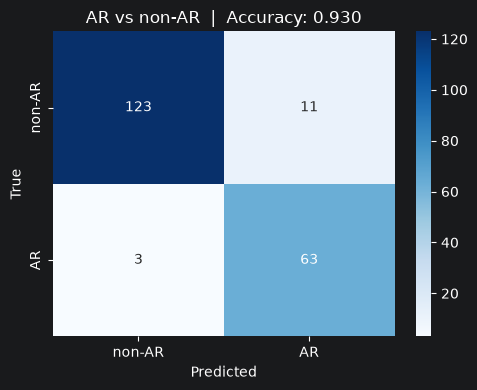

In [3]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns

# --- Aromatic prediction: AR vs non-AR ---
ar_df = results_df.copy()
ar_df["true_AR"] = (ar_df["true_category"] == "AR").astype(int)
ar_df["pred_AR"] = (ar_df["pred_category"] == "AR").astype(int)

y_true = ar_df["true_AR"]
y_pred = ar_df["pred_AR"]

labels = ["non-AR", "AR"]
cm = confusion_matrix(y_true, y_pred)
acc = accuracy_score(y_true, y_pred)

print("=== Aromatic vs Non-Aromatic Prediction ===")
print(f"Accuracy: {acc:.3f}")
print(classification_report(y_true, y_pred, target_names=labels))

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title(f"AR vs non-AR  |  Accuracy: {acc:.3f}")
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "confusion_ar.png"), dpi=150)
plt.show()


Entries with size categories: 132
Entries where NN also has size category: 119
Accuracy (size categories only): 0.756
              precision    recall  f1-score   support

        LCFA       0.83      0.85      0.84        67
        MCFA       0.68      0.65      0.67        23
        SCFA       0.64      0.62      0.63        29

    accuracy                           0.76       119
   macro avg       0.72      0.71      0.71       119
weighted avg       0.75      0.76      0.75       119



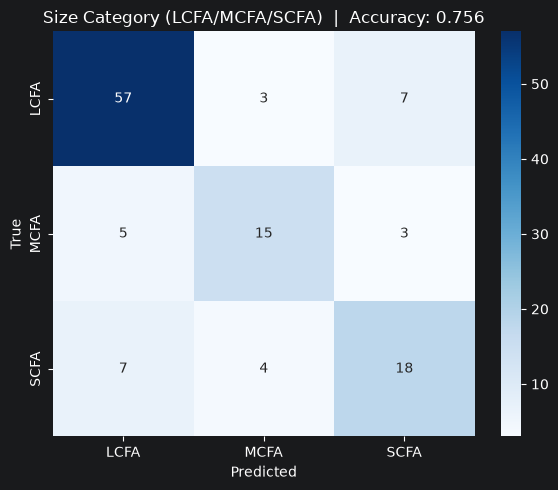

In [4]:
# --- Size prediction: LCFA vs MCFA vs SCFA (exclude AR and FA) ---
size_cats = {"SCFA", "MCFA", "LCFA"}

# Keep only rows where true category is a size category
size_df = results_df[results_df["true_category"].isin(size_cats)].copy()
print(f"Entries with size categories: {len(size_df)}")

# For entries whose NN is outside size cats, report as-is
size_df["pred_size"] = size_df["pred_category"].apply(
    lambda x: x if x in size_cats else f"other({x})"
)

# Confusion matrix restricted to rows where NN is also a size category
size_both = size_df[size_df["pred_size"].isin(size_cats)]
print(f"Entries where NN also has size category: {len(size_both)}")

acc_s = accuracy_score(size_both["true_category"], size_both["pred_size"])
print(f"Accuracy (size categories only): {acc_s:.3f}")
print(classification_report(size_both["true_category"], size_both["pred_size"],
                             labels=sorted(size_cats)))

labels_s = sorted(size_cats)
cm_s = confusion_matrix(size_both["true_category"], size_both["pred_size"],
                         labels=labels_s)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_s, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels_s, yticklabels=labels_s, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title(f"Size Category (LCFA/MCFA/SCFA)  |  Accuracy: {acc_s:.3f}")
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "confusion_size.png"), dpi=150)
plt.show()


Rows with known 3OH: 118
=== Beta-Hydroxylation (3OH) Prediction ===
Accuracy: 0.746
              precision    recall  f1-score   support

  0 (no 3OH)       0.77      0.75      0.76        63
     1 (3OH)       0.72      0.75      0.73        55

    accuracy                           0.75       118
   macro avg       0.74      0.75      0.75       118
weighted avg       0.75      0.75      0.75       118



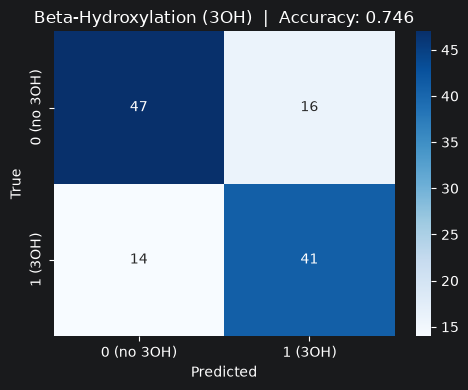

In [5]:
# --- Beta-hydroxylation prediction: 3OH 1 vs 0 ---
# Only evaluate rows where true_3OH is known; pred_3OH always comes from a valid-3OH neighbor
oh_df = results_df[results_df["true_3OH"].notna()].copy()
oh_df["true_3OH"] = oh_df["true_3OH"].astype(int)
oh_df["pred_3OH"] = oh_df["pred_3OH"].astype(int)
print(f"Rows with known 3OH: {len(oh_df)}")

y_true_oh = oh_df["true_3OH"]
y_pred_oh = oh_df["pred_3OH"]

labels_oh = ["0 (no 3OH)", "1 (3OH)"]
cm_oh = confusion_matrix(y_true_oh, y_pred_oh)
acc_oh = accuracy_score(y_true_oh, y_pred_oh)

print("=== Beta-Hydroxylation (3OH) Prediction ===")
print(f"Accuracy: {acc_oh:.3f}")
print(classification_report(y_true_oh, y_pred_oh, target_names=labels_oh))

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_oh, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels_oh, yticklabels=labels_oh, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title(f"Beta-Hydroxylation (3OH)  |  Accuracy: {acc_oh:.3f}")
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "confusion_3oh.png"), dpi=150)
plt.show()
